In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/clean_listings.csv")

# Check property types we have
print(df["type"].value_counts())

type
Apartment           377
Villa                37
Compound             24
Hotel Apartments     21
Townhouse             7
Whole Building        1
Name: count, dtype: int64


In [9]:
# K-Means only works with numbers, so we convert property type to numbers
# This is called "label encoding"
type_mapping = {t: i for i, t in enumerate(df["type"].unique())}
print("Type encoding:", type_mapping)

df["type_encoded"] = df["type"].map(type_mapping)

# Select features for clustering
features = ["price_qar", "area_sqm", "bedrooms", "bathrooms", "type_encoded"]
X = df[features].dropna()

print(f"\nListings available for clustering: {len(X)}")

Type encoding: {'Apartment': 0, 'Villa': 1, 'Compound': 2, 'Hotel Apartments': 3, 'Townhouse': 4, 'Whole Building': 5}

Listings available for clustering: 466


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

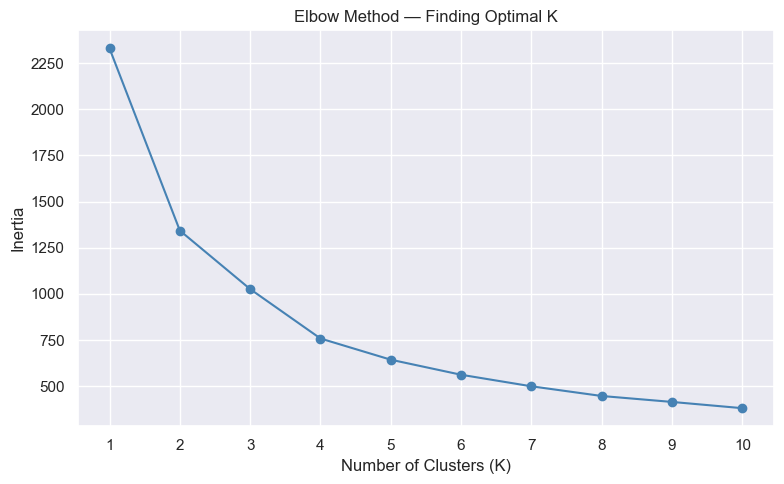

In [11]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color="steelblue")
plt.title("Elbow Method — Finding Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("../data/elbow_plot.png")
plt.show()

In [17]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clustered = df.loc[X.index].copy()
df_clustered["cluster"] = km.fit_predict(X_scaled)

# Auto-label by average price per cluster
cluster_avg = df_clustered.groupby("cluster")["price_qar"].mean().sort_values()
label_map = {
    cluster_avg.index[0]: "Budget",
    cluster_avg.index[1]: "Mid-Range",
    cluster_avg.index[2]: "Premium",
    cluster_avg.index[3]: "Luxury"
}
df_clustered["segment"] = df_clustered["cluster"].map(label_map)

print(df_clustered.groupby("segment")[["price_qar", "area_sqm", "bedrooms"]].mean().round(1))

           price_qar  area_sqm  bedrooms
segment                                 
Budget        6321.0      98.2       1.4
Luxury       17879.6     385.4       4.3
Mid-Range     8227.4      97.4       1.3
Premium      10254.9     159.4       2.5


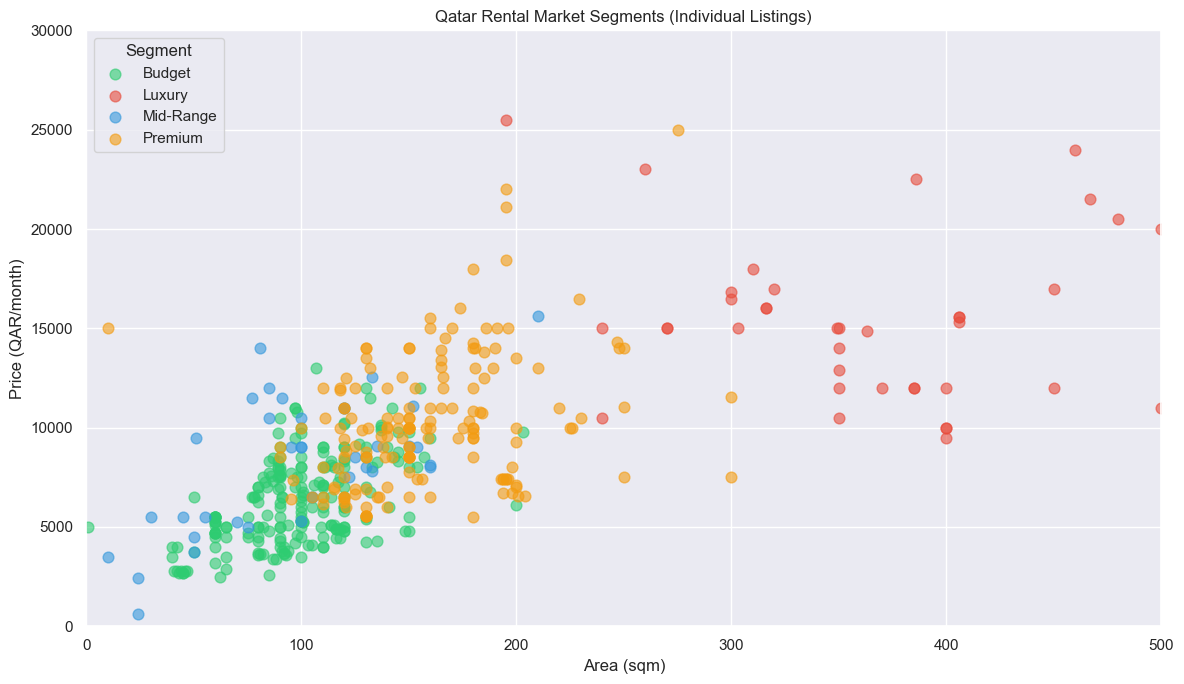

In [19]:
colors = {
    "Budget":    "#2ecc71",
    "Mid-Range": "#3498db",
    "Premium":   "#f39c12",
    "Luxury":    "#e74c3c"
}

plt.figure(figsize=(12, 7))
for segment, group in df_clustered.groupby("segment"):
    plt.scatter(group["area_sqm"], group["price_qar"],
                label=segment, color=colors[segment],
                alpha=0.6, s=60)

plt.title("Qatar Rental Market Segments (Individual Listings)")
plt.xlabel("Area (sqm)")
plt.ylabel("Price (QAR/month)")
plt.legend(title="Segment", fontsize=11)
plt.xlim(0, 500)
plt.ylim(0, 30000)
plt.tight_layout()
plt.savefig("../data/cluster_map.png")
plt.show()

In [14]:
df_clustered.to_csv("../data/clean_listings.csv", index=False)
print(df_clustered["segment"].value_counts())
print("\nSample from each segment:")
print(df_clustered.groupby("segment")[["title", "type", "district", "price_qar", "area_sqm"]].first())

segment
Budget       355
Luxury        74
Mid-Range     37
Name: count, dtype: int64

Sample from each segment:
                                                       title       type  \
segment                                                                   
Budget     Modern 3 BHK APT | Fully Furnished | In Al Man...  Apartment   
Luxury         Elegant 3 BR | Full Sea View | Don’t Miss Out  Apartment   
Mid-Range           LANDLORD DIRECT | 2BR Flat at Yvillage 2   Compound   

                   district  price_qar  area_sqm  
segment                                           
Budget          Al Mansoura       7000     200.0  
Luxury     The Pearl Island      14000     190.0  
Mid-Range        Al Messila      11077     152.0  
